In [1]:
##1. Importing the libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.io as pio

pio.renderers.default = "svg"

In [2]:
##2. Importing the dataset

raw_df = pd.read_csv('Zomato Chennai Listing 2020.csv')

In [3]:
##2. Importing the dataset

raw_df.head()

,Zomato URL,Name of Restaurant,Address,Location,Cuisine,Top Dishes,Price for 2,Dining Rating,Dining Rating Count,Delivery Rating,Delivery Rating Count,Features
0,https://www.zomato.com/chennai/yaa-mohaideen-b...,Yaa Mohaideen Briyani,"336 & 338, Main Road, Pallavaram, Chennai",Pallavaram,['Biryani'],"['Bread Halwa', ' Chicken 65', ' Mutton Biryan...",500.0,4.3,1500,4.3,9306,"['Home Delivery', 'Indoor Seating']"
1,https://www.zomato.com/chennai/sukkubhai-biriy...,Sukkubhai Biriyani,"New 14, Old 11/3Q, Railway Station Road, MKN ...",Alandur,"['Biryani', ' North Indian', ' Mughlai', ' Des...","['Beef Biryani', ' Beef Fry', ' Paratha', ' Pa...",1000.0,4.4,3059,4.1,39200,"['Home Delivery', 'Free Parking', 'Table booki..."
2,https://www.zomato.com/chennai/ss-hyderabad-bi...,SS Hyderabad Biryani,"98/339, Arcot Road, Opposite Gokulam Chit Fun...",Kodambakkam,"['Biryani', ' North Indian', ' Chinese', ' Ara...","['Brinjal Curry', ' Tandoori Chicken', ' Chick...",500.0,4.3,1361,4.4,10500,"['Home Delivery', 'Indoor Seating']"
3,https://www.zomato.com/chennai/kfc-perambur,KFC,"10, Periyar Nagar, 70 Feet Road, Near Sheeba ...",Perambur,"['Burger', ' Fast Food', ' Finger Food', ' Bev...",['Zinger Burger'],500.0,4.0,1101,4.0,11200,"['Home Delivery', 'Free Parking', 'Card Upon D..."
4,https://www.zomato.com/chennai/tasty-kitchen-p...,Tasty Kitchen,"135B, SRP Colony, Peravallur, Near Perambur, ...",Perambur,"['Chinese', ' Biryani', ' North Indian', ' Che...","['Mutton Biryani', ' Chicken Rice', ' Tomato R...",450.0,4.2,617,4.1,22400,"['Home Delivery', 'Indoor Seating']"


In [4]:
##3. Getting Basic Information about the Dataset

raw_df.shape

(12032, 12)

In [5]:
##3. Getting Basic Information about the Dataset

raw_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12032 entries, 0 to 12031
Data columns (total 12 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Zomato URL             12032 non-null  object 
 1   Name of Restaurant     12032 non-null  object 
 2   Address                12032 non-null  object 
 3   Location               12032 non-null  object 
 4   Cuisine                12032 non-null  object 
 5   Top Dishes             12032 non-null  object 
 6   Price for 2            12032 non-null  float64
 7   Dining Rating          6681 non-null   float64
 8   Dining Rating Count    11812 non-null  object 
 9   Delivery Rating        6181 non-null   float64
 10  Delivery Rating Count  11812 non-null  object 
 11  Features               12032 non-null  object 
dtypes: float64(3), object(9)
memory usage: 1.1+ MB


In [6]:
##3. Getting Basic Information about the Dataset

raw_df.describe()

,Price for 2,Dining Rating,Delivery Rating
count,12032.000000,6681.000000,6181.000000
mean,397.611370,3.387756,3.805290
std,332.045938,0.558181,0.374213
min,40.000000,0.300000,0.300000
25%,200.000000,3.100000,3.600000
50%,300.000000,3.500000,3.900000
75%,450.000000,3.800000,4.000000
max,5000.000000,4.900000,4.700000


In [7]:
##4. Cleaning the Dataset - a. Preparing the Chennai columns for analysis

# Checking duplicate records
raw_df[raw_df.duplicated()]

,Zomato URL,Name of Restaurant,Address,Location,Cuisine,Top Dishes,Price for 2,Dining Rating,Dining Rating Count,Delivery Rating,Delivery Rating Count,Features


In [8]:
##4. Cleaning the Dataset - a. Preparing the Chennai columns for analysis

# Removing duplicate records
raw_df = raw_df.drop_duplicates().copy()

In [9]:
##4. Cleaning the Dataset - a. Preparing the Chennai columns for analysis

# Renaming Chennai dataset columns to match the Mumbai assignment structure
raw_df.rename(columns={
    'Zomato URL': 'URL',
    'Name of Restaurant': 'NAME',
    'Price for 2': 'PRICE',
    'Cuisine': 'CUSINE_CATEGORY',
    'Location': 'REGION',
    'Dining Rating': 'RATING',
    'Dining Rating Count': 'VOTES'
}, inplace=True)

# Keeping the original Chennai columns needed for analysis
raw_df.head()

,URL,NAME,Address,REGION,CUSINE_CATEGORY,Top Dishes,PRICE,RATING,VOTES,Delivery Rating,Delivery Rating Count,Features
0,https://www.zomato.com/chennai/yaa-mohaideen-b...,Yaa Mohaideen Briyani,"336 & 338, Main Road, Pallavaram, Chennai",Pallavaram,['Biryani'],"['Bread Halwa', ' Chicken 65', ' Mutton Biryan...",500.0,4.3,1500,4.3,9306,"['Home Delivery', 'Indoor Seating']"
1,https://www.zomato.com/chennai/sukkubhai-biriy...,Sukkubhai Biriyani,"New 14, Old 11/3Q, Railway Station Road, MKN ...",Alandur,"['Biryani', ' North Indian', ' Mughlai', ' Des...","['Beef Biryani', ' Beef Fry', ' Paratha', ' Pa...",1000.0,4.4,3059,4.1,39200,"['Home Delivery', 'Free Parking', 'Table booki..."
2,https://www.zomato.com/chennai/ss-hyderabad-bi...,SS Hyderabad Biryani,"98/339, Arcot Road, Opposite Gokulam Chit Fun...",Kodambakkam,"['Biryani', ' North Indian', ' Chinese', ' Ara...","['Brinjal Curry', ' Tandoori Chicken', ' Chick...",500.0,4.3,1361,4.4,10500,"['Home Delivery', 'Indoor Seating']"
3,https://www.zomato.com/chennai/kfc-perambur,KFC,"10, Periyar Nagar, 70 Feet Road, Near Sheeba ...",Perambur,"['Burger', ' Fast Food', ' Finger Food', ' Bev...",['Zinger Burger'],500.0,4.0,1101,4.0,11200,"['Home Delivery', 'Free Parking', 'Card Upon D..."
4,https://www.zomato.com/chennai/tasty-kitchen-p...,Tasty Kitchen,"135B, SRP Colony, Peravallur, Near Perambur, ...",Perambur,"['Chinese', ' Biryani', ' North Indian', ' Che...","['Mutton Biryani', ' Chicken Rice', ' Tomato R...",450.0,4.2,617,4.1,22400,"['Home Delivery', 'Indoor Seating']"


In [10]:
##4. Cleaning the Dataset - b. Checking and handling missing records

# Checking for null records
raw_df.isnull().sum()

URL                         0
NAME                        0
Address                     0
REGION                      0
CUSINE_CATEGORY             0
Top Dishes                  0
PRICE                       0
RATING                   5351
VOTES                     220
Delivery Rating          5851
Delivery Rating Count     220
Features                    0
dtype: int64

In [11]:
##4. Cleaning the Dataset - b. Checking and handling missing records

# Checking records with missing dining ratings
raw_df[raw_df['RATING'].isnull()].head()

,URL,NAME,Address,REGION,CUSINE_CATEGORY,Top Dishes,PRICE,RATING,VOTES,Delivery Rating,Delivery Rating Count,Features
6,https://www.zomato.com/chennai/bai-veetu-kalya...,Bai Veetu Kalyanam,"1/187, Thalambur Road, Navallur, Chennai",Navallur,['Biryani'],"['Bread Halwa', ' Mutton Biryani', ' Brinjal G...",350.0,NaN,Does not offer Dining,4.3,1061,['Home Delivery']
77,https://www.zomato.com/chennai/al-dhareeq-beef...,Al Dhareeq Beef Biriyani,"64/A, 162, Sivan Kovil South Street, Kodambak...",Kodambakkam,['Biryani'],['Beef Biryani'],300.0,NaN,Does not offer Dining,3.9,19600,['Home Delivery']
106,https://www.zomato.com/chennai/twilight-take-o...,Twilight Take Out,"1, Park Side Street, Lake Area, Nungambakkam,...",Nungambakkam,"['North Indian', ' Chinese', ' Rolls', ' Conti...","['Club Sandwich', ' Chicken Tikka Roll', ' Chi...",350.0,NaN,Does not offer Dining,4.0,11200,"['Home Delivery', 'Free Parking']"
107,https://www.zomato.com/chennai/the-red-box-ann...,The Red Box,"Flat 51/C, Shanthi Colony Main Road, Anna Nag...",Anna Nagar West,['Chinese'],"['Noodle', ' Chilli Chicken Gravy', ' Dragon C...",200.0,NaN,Does not offer Dining,4.2,11500,['Home Delivery']
114,https://www.zomato.com/chennai/charminar-biriy...,Charminar Biriyani Centre,"91, Dr. Besant Road, Near Meesapet Market, Ro...",Royapettah,"['Biryani', ' North Indian']","['Chicken Biryani', ' Bread Halwa', ' Brinjal ...",300.0,NaN,Does not offer Dining,3.9,652,"['Home Delivery', 'Standing Tables']"


In [12]:
##4. Cleaning the Dataset - b. Checking and handling missing records

# Convert rating and vote-count fields to numeric values where possible
raw_df['RATING'] = pd.to_numeric(raw_df['RATING'], errors='coerce')
raw_df['VOTES'] = pd.to_numeric(raw_df['VOTES'].astype(str).str.replace(',', '', regex=False), errors='coerce')
raw_df['PRICE'] = pd.to_numeric(raw_df['PRICE'], errors='coerce')

raw_df[['RATING', 'VOTES', 'PRICE']].isnull().sum()

RATING    5351
VOTES     5351
PRICE        0
dtype: int64

In [13]:
##4. Cleaning the Dataset - c. Creating cuisine type for analysis

# Cuisine is stored as a list-like text field. Use the first listed cuisine as the primary cuisine type.
# This keeps the analysis close to the Mumbai assignment's CUSINE TYPE column.
def get_primary_cuisine(value):
    cuisines = str(value).strip().strip('[]')
    if not cuisines:
        return 'Unknown'
    first = cuisines.split(',')[0].strip().strip("'").strip('"')
    return first if first else 'Unknown'

raw_df['CUSINE TYPE'] = raw_df['CUSINE_CATEGORY'].apply(get_primary_cuisine)
raw_df['CUSINE TYPE'].value_counts().head(20)

CUSINE TYPE
South Indian    2002
North Indian    1489
Biryani         1061
Fast Food        997
Bakery           875
Chinese          867
Beverages        647
Ice Cream        425
Pizza            313
Mithai           258
Desserts         255
Cafe             246
Street Food      232
Sandwich         227
Burger           194
Chettinad        188
Juices           160
Italian          154
Arabian          124
Continental      119
Name: count, dtype: int64

In [14]:
##4. Cleaning the Dataset - d. Working with dining and delivery ratings

# Chennai dataset does not contain restaurant opening TIMING or DAYS_OPEN columns.
# Check dining and delivery rating availability instead.

raw_df[['RATING', 'VOTES', 'Delivery Rating', 'Delivery Rating Count']].head()

,RATING,VOTES,Delivery Rating,Delivery Rating Count
0,4.3,1500.0,4.3,9306
1,4.4,3059.0,4.1,39200
2,4.3,1361.0,4.4,10500
3,4.0,1101.0,4.0,11200
4,4.2,617.0,4.1,22400


In [15]:
##4. Cleaning the Dataset - d. Working with dining and delivery ratings

# Convert delivery ratings and review counts to numeric values where possible

raw_df['Delivery Rating'] = pd.to_numeric(raw_df['Delivery Rating'], errors='coerce')
raw_df['Delivery Rating Count'] = pd.to_numeric(
    raw_df['Delivery Rating Count'].astype(str).str.replace(',', '', regex=False),
    errors='coerce'
)

raw_df[['RATING', 'VOTES', 'Delivery Rating', 'Delivery Rating Count']].isnull().sum()

RATING                   5351
VOTES                    5351
Delivery Rating          5851
Delivery Rating Count    5851
dtype: int64

In [16]:
##4. Cleaning the Dataset - e. Removing restaurant records without a dining rating or review count

# Finding restaurants whose dining rating or dining rating count is missing/zero

useless_data = raw_df['RATING'].isnull() | raw_df['VOTES'].isnull() | (raw_df['RATING'] <= 0) | (raw_df['VOTES'] <= 0)
raw_df[useless_data].head()

,URL,NAME,Address,REGION,CUSINE_CATEGORY,Top Dishes,PRICE,RATING,VOTES,Delivery Rating,Delivery Rating Count,Features,CUSINE TYPE
6,https://www.zomato.com/chennai/bai-veetu-kalya...,Bai Veetu Kalyanam,"1/187, Thalambur Road, Navallur, Chennai",Navallur,['Biryani'],"['Bread Halwa', ' Mutton Biryani', ' Brinjal G...",350.0,NaN,NaN,4.3,1061.0,['Home Delivery'],Biryani
77,https://www.zomato.com/chennai/al-dhareeq-beef...,Al Dhareeq Beef Biriyani,"64/A, 162, Sivan Kovil South Street, Kodambak...",Kodambakkam,['Biryani'],['Beef Biryani'],300.0,NaN,NaN,3.9,19600.0,['Home Delivery'],Biryani
106,https://www.zomato.com/chennai/twilight-take-o...,Twilight Take Out,"1, Park Side Street, Lake Area, Nungambakkam,...",Nungambakkam,"['North Indian', ' Chinese', ' Rolls', ' Conti...","['Club Sandwich', ' Chicken Tikka Roll', ' Chi...",350.0,NaN,NaN,4.0,11200.0,"['Home Delivery', 'Free Parking']",North Indian
107,https://www.zomato.com/chennai/the-red-box-ann...,The Red Box,"Flat 51/C, Shanthi Colony Main Road, Anna Nag...",Anna Nagar West,['Chinese'],"['Noodle', ' Chilli Chicken Gravy', ' Dragon C...",200.0,NaN,NaN,4.2,11500.0,['Home Delivery'],Chinese
114,https://www.zomato.com/chennai/charminar-biriy...,Charminar Biriyani Centre,"91, Dr. Besant Road, Near Meesapet Market, Ro...",Royapettah,"['Biryani', ' North Indian']","['Chicken Biryani', ' Bread Halwa', ' Brinjal ...",300.0,NaN,NaN,3.9,652.0,"['Home Delivery', 'Standing Tables']",Biryani


In [17]:
##4. Cleaning the Dataset - e. Removing restaurant records without a dining rating or review count

# Keep records with a valid dining rating and dining review count
raw_df = raw_df[~useless_data].copy()

In [18]:
##4. Cleaning the Dataset - f. Creating a RATING_TYPE column

# Create rating categories based on the dining rating
def rating_type(rating):
    if rating >= 4.5:
        return 'Excellent'
    elif rating >= 4.0:
        return 'Very Good'
    elif rating >= 3.5:
        return 'Good'
    elif rating >= 3.0:
        return 'Average'
    elif rating >= 2.0:
        return 'Poor'
    else:
        return 'Very Poor'

raw_df['RATING_TYPE'] = raw_df['RATING'].apply(rating_type)
raw_df['RATING_TYPE'].value_counts()

RATING_TYPE
Good         2501
Average      2054
Poor         1214
Very Good     815
Excellent      76
Very Poor       1
Name: count, dtype: int64

In [19]:
##4. Cleaning the Dataset - g. Working with the REGION column

# Checking the regions/locations in Chennai
raw_df['REGION'].value_counts().head(30)

REGION
Porur              209
T. Nagar           188
Velachery          186
Anna Nagar East    180
Ambattur           174
Nungambakkam       147
Perambur           146
Ramapuram          143
Perungudi          140
Medavakkam         132
Anna Nagar West    127
Tambaram           122
Adyar              122
GST Road           121
Kilpauk            119
Selaiyur           119
Mogappair          119
Thuraipakkam       117
Pallavaram         110
Chromepet          101
Ashok Nagar        100
Kolathur            98
Madipakkam          94
Poonamalle          93
Mylapore            87
Egmore              85
Sholinganallur      77
K.K. Nagar          76
Triplicane          75
Potheri             74
Name: count, dtype: int64

In [20]:
##4. Cleaning the Dataset - g. Working with the REGION column

# Remove extra spaces from location names
raw_df['REGION'] = raw_df['REGION'].astype(str).str.strip()
raw_df['REGION'].value_counts().head(30)

REGION
Porur              209
T. Nagar           188
Velachery          186
Anna Nagar East    180
Ambattur           174
Nungambakkam       147
Perambur           146
Ramapuram          143
Perungudi          140
Medavakkam         132
Anna Nagar West    127
Tambaram           122
Adyar              122
GST Road           121
Kilpauk            119
Selaiyur           119
Mogappair          119
Thuraipakkam       117
Pallavaram         110
Chromepet          101
Ashok Nagar        100
Kolathur            98
Madipakkam          94
Poonamalle          93
Mylapore            87
Egmore              85
Sholinganallur      77
K.K. Nagar          76
Triplicane          75
Potheri             74
Name: count, dtype: int64

In [21]:
##4. Cleaning the Dataset - h. Removing duplicate records

# Finding duplicate rows after column preparation
raw_df[raw_df.duplicated()].head()

,URL,NAME,Address,REGION,CUSINE_CATEGORY,Top Dishes,PRICE,RATING,VOTES,Delivery Rating,Delivery Rating Count,Features,CUSINE TYPE,RATING_TYPE


In [22]:
##4. Cleaning the Dataset - h. Removing duplicate records

# Dropping duplicate rows
raw_df = raw_df.drop_duplicates().copy()

In [23]:
##4. Copying the cleaned data into a new DataFrame

zomato_df = raw_df.copy()

In [24]:
##4. Copying the cleaned data into a new DataFrame

zomato_df.head()

,URL,NAME,Address,REGION,CUSINE_CATEGORY,Top Dishes,PRICE,RATING,VOTES,Delivery Rating,Delivery Rating Count,Features,CUSINE TYPE,RATING_TYPE
0,https://www.zomato.com/chennai/yaa-mohaideen-b...,Yaa Mohaideen Briyani,"336 & 338, Main Road, Pallavaram, Chennai",Pallavaram,['Biryani'],"['Bread Halwa', ' Chicken 65', ' Mutton Biryan...",500.0,4.3,1500.0,4.3,9306.0,"['Home Delivery', 'Indoor Seating']",Biryani,Very Good
1,https://www.zomato.com/chennai/sukkubhai-biriy...,Sukkubhai Biriyani,"New 14, Old 11/3Q, Railway Station Road, MKN ...",Alandur,"['Biryani', ' North Indian', ' Mughlai', ' Des...","['Beef Biryani', ' Beef Fry', ' Paratha', ' Pa...",1000.0,4.4,3059.0,4.1,39200.0,"['Home Delivery', 'Free Parking', 'Table booki...",Biryani,Very Good
2,https://www.zomato.com/chennai/ss-hyderabad-bi...,SS Hyderabad Biryani,"98/339, Arcot Road, Opposite Gokulam Chit Fun...",Kodambakkam,"['Biryani', ' North Indian', ' Chinese', ' Ara...","['Brinjal Curry', ' Tandoori Chicken', ' Chick...",500.0,4.3,1361.0,4.4,10500.0,"['Home Delivery', 'Indoor Seating']",Biryani,Very Good
3,https://www.zomato.com/chennai/kfc-perambur,KFC,"10, Periyar Nagar, 70 Feet Road, Near Sheeba ...",Perambur,"['Burger', ' Fast Food', ' Finger Food', ' Bev...",['Zinger Burger'],500.0,4.0,1101.0,4.0,11200.0,"['Home Delivery', 'Free Parking', 'Card Upon D...",Burger,Very Good
4,https://www.zomato.com/chennai/tasty-kitchen-p...,Tasty Kitchen,"135B, SRP Colony, Peravallur, Near Perambur, ...",Perambur,"['Chinese', ' Biryani', ' North Indian', ' Che...","['Mutton Biryani', ' Chicken Rice', ' Tomato R...",450.0,4.2,617.0,4.1,22400.0,"['Home Delivery', 'Indoor Seating']",Chinese,Very Good


In [25]:
%pip install -U "kaleido>=1"

Note: you may need to restart the kernel to use updated packages.


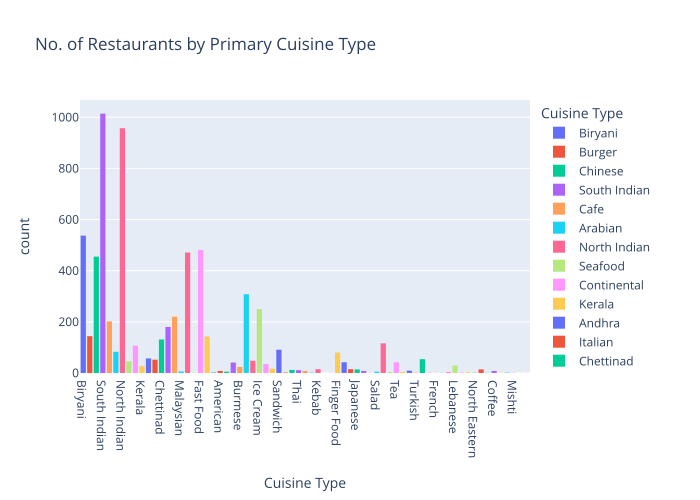

In [26]:
##5. Performing Exploratory Data Analysis

## Q1) How many restaurants are there in Chennai for each primary cuisine type?

fig = px.histogram(
    zomato_df, x='CUSINE TYPE', color='CUSINE TYPE',
    title='No. of Restaurants by Primary Cuisine Type',
    labels={'CUSINE TYPE': 'Cuisine Type'}
)
fig.show()

In [27]:
##5. Performing Exploratory Data Analysis

## Q2) What is the percentage of restaurants by Rating Type in Chennai?

rating_type_df = zomato_df['RATING_TYPE'].value_counts().reset_index()
rating_type_df.columns = ['RATING TYPE', 'COUNT OF RESTAURANTS']
rating_type_df

,RATING TYPE,COUNT OF RESTAURANTS
0,Good,2501
1,Average,2054
2,Poor,1214
3,Very Good,815
4,Excellent,76
5,Very Poor,1


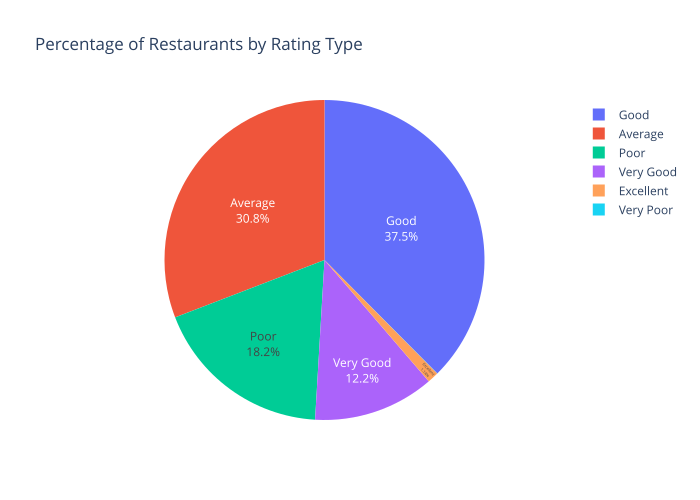

In [28]:
##5. Performing Exploratory Data Analysis

## Q2) What is the percentage of restaurants by Rating Type in Chennai?

fig = px.pie(
    rating_type_df, names='RATING TYPE', values='COUNT OF RESTAURANTS',
    color='RATING TYPE', title='Percentage of Restaurants by Rating Type'
).update_traces(textposition='inside', textinfo='percent+label')
fig.show()

In [29]:
##5. Performing Exploratory Data Analysis

## Q3) Which are the Top 10 highest rated Seafood restaurants in Chennai?

seafood_df = zomato_df[zomato_df['CUSINE_CATEGORY'].str.contains('Seafood', case=False, na=False)]
seafood_df.sort_values(by='RATING', ascending=False).head(10)

,URL,NAME,Address,REGION,CUSINE_CATEGORY,Top Dishes,PRICE,RATING,VOTES,Delivery Rating,Delivery Rating Count,Features,CUSINE TYPE,RATING_TYPE
195,https://www.zomato.com/chennai/the-marina-nung...,The Marina,"39, College Road, Nungambakkam, Chennai",Nungambakkam,"['Seafood', ' North Indian', ' Chinese']","['Sea Food', ' Jumbo Prawns', ' Biryani', ' Fi...",1600.0,4.8,1082.0,4.3,373.0,"['Home Delivery', 'Indoor Seating', 'Table res...",Seafood,Excellent
214,https://www.zomato.com/chennai/sera-the-tapas-...,Sera - The Tapas Bar & Restaurant,"71, Cathedral Road, Gopalapuram, Chennai",Gopalapuram,"['Finger Food', ' Seafood', ' Italian', ' Cont...","['Cocktails', ' Pasta', ' Nachos', ' Mashed Po...",1600.0,4.5,964.0,3.4,50.0,"['Home Delivery', 'Full Bar Available', 'Free ...",Finger Food,Excellent
292,https://www.zomato.com/chennai/alchemy-bar-lou...,Alchemy Bar & Lounge,"180, TTK Road, Alwarpet, Chennai","Hotel Rajpark, Alwarpet","['Continental', ' Finger Food', ' Seafood', ' ...","['Cocktails', ' Fries', ' Brownie', ' Peri Per...",2000.0,4.5,432.0,NaN,NaN,"['Full Bar Available', 'Live Sports Screening'...",Continental,Excellent
96,https://www.zomato.com/chennai/urban-spatula-a...,Urban Spatula,"Plot 1633, 54, H-Block, Ground Floor, 13th Ma...",Anna Nagar West,"['Continental', ' Seafood', ' Biryani', ' Ital...","['Burgers', ' Pasta', ' Fish', ' Fries', ' Chi...",800.0,4.4,794.0,4.3,911.0,"['Home Delivery', 'Free Parking', 'Table booki...",Continental,Very Good
315,https://www.zomato.com/chennai/layalee-ekkadut...,Layalee,"12A, Near Jaya TV Signal, Jawaharlal Nehru Ro...",Ekkaduthangal,"['Arabian', ' BBQ', ' Seafood', ' Chinese', ' ...","['Fish', ' Faluda', ' Shawarma', ' Brownie', '...",700.0,4.4,586.0,4.1,143.0,"['Home Delivery', 'Table booking recommended',...",Arabian,Very Good
342,https://www.zomato.com/chennai/lattitude-49-ma...,L'attitude 49,"Grande Bay Resort, 123, East Raja Street, Kov...",Grande Bay Resort,"['Singaporean', ' Thai', ' Asian', ' Chinese',...","['Sea Food', ' Fish', ' Pasta', ' Noodle', ' B...",1800.0,4.4,563.0,NaN,NaN,"['Breakfast', 'Wheelchair Accessible', 'Full B...",Singaporean,Very Good
282,https://www.zomato.com/chennai/bay-view-taj-fi...,Bay View - Taj Fisherman's Cove Resort & Spa,"Vivanta by Taj Fisherman's Cove, Covelong Be...","Taj Fisherman's Cove Resort & Spa, Kanchipuram...","['Seafood', ' South Indian', ' Andhra', ' Kera...","['Sea Food', ' Fish Curry', ' Chips', ' Cockta...",3500.0,4.4,678.0,NaN,NaN,"['Wheelchair Accessible', 'Full Bar Available'...",Seafood,Very Good
358,https://www.zomato.com/chennai/the-wharf-2-0-r...,The Wharf 2.0 - Radisson BLU Templebay,"Radisson BLU Templebay, 57, Covelong Road,, ...","Radisson Blu Temple Bay, Mamallapuram","['Seafood', ' Mediterranean', ' Italian', ' No...","['Sea Food', ' Jumbo Prawns', ' Pasta', ' Fish...",3000.0,4.4,517.0,NaN,NaN,"['Wheelchair Accessible', 'Full Bar Available'...",Seafood,Very Good
133,https://www.zomato.com/chennai/azzuri-bay-adyar,Azzuri Bay,"13, 1st Crescent Road, Gandhinagar, Adyar, Ch...",Adyar,"['Italian', ' Mediterranean', ' Thai', ' Seafo...","['Pasta', ' Pizza', ' Sea Food', ' Tiramisu', ...",1000.0,4.3,2430.0,4.0,369.0,"['Home Delivery', 'Rooftop', 'Table reservatio...",Italian,Very Good
64,https://www.zomato.com/chennai/samco-velachery,Samco,"21/33, Velachery Main Road, Velachery, Chennai",Velachery,"['Arabian', ' Chinese', ' North Indian', ' Sea...","['Biryani', ' Bbq Chicken', ' Faluda', ' Peppe...",800.0,4.3,1078.0,3.7,3862.0,"['Home Delivery', 'Valet Parking Available', '...",Arabian,Very Good


In [30]:
##5. Performing Exploratory Data Analysis

## Q4) Which restaurants have the highest dining ratings among Biryani restaurants in Chennai?

biryani_df = zomato_df[zomato_df['CUSINE_CATEGORY'].str.contains('Biryani', case=False, na=False)]
biryani_df.sort_values(by='RATING', ascending=False).head(10)

,URL,NAME,Address,REGION,CUSINE_CATEGORY,Top Dishes,PRICE,RATING,VOTES,Delivery Rating,Delivery Rating Count,Features,CUSINE TYPE,RATING_TYPE
116,https://www.zomato.com/chennai/al-maza-anna-na...,AlMaza,"30, A Block, 6th Street, Near Titan Showroom,...",Anna Nagar East,"['Arabian', ' Mughlai', ' North Indian', ' Bir...","['Faluda', ' Rara Gosht', ' Buttermilk', ' Naa...",1000.0,4.6,764.0,4.2,881.0,"['Home Delivery', 'Indoor Seating', 'Table boo...",Arabian,Excellent
199,https://www.zomato.com/chennai/arabian-kebab-c...,Arabian Kebab Center,"17/5, Station View Road, Kodambakkam, Chennai",Kodambakkam,"['Biryani', ' North Indian', ' Kebab']","['Shawarma', ' Chicken Grill', ' Brinjal Gravy...",400.0,4.6,798.0,NaN,NaN,"['Takeaway Only', 'Free Parking']",Biryani,Excellent
9037,https://www.zomato.com/chennai/palmshore-medav...,Palmshore,"4/581 A, Velachery Main Road, Senthamizh Naga...",Medavakkam,"['North Indian', ' Chinese', ' Arabian', ' BBQ...","['Mutton Mandi', ' Biryani', ' Brownie', ' Bbq...",1000.0,4.5,1942.0,3.8,4379.0,"['Home Delivery', 'Valet Parking Available', '...",North Indian,Excellent
8757,https://www.zomato.com/chennai/yaa-mohaideen-b...,Yaa Mohaideen Biryani,"4/158, Church Road, Opposite Uzhavar Santhai ...",Pallavaram,"['Biryani', ' Chinese', ' Tamil']","['Mutton Biryani', ' Chicken 65', ' Chicken Bi...",600.0,4.5,3414.0,NaN,NaN,"['Indoor Seating', 'Table Reservation Not Requ...",Biryani,Excellent
154,https://www.zomato.com/chennai/nair-mess-tripl...,Nair Mess,"22, Mohammed Abdullah, 2nd Street, Opposite C...",Triplicane,"['South Indian', ' Biryani']","['Fish Fry', ' Omelette', ' Vanjaram Fry', ' M...",200.0,4.5,1038.0,NaN,NaN,['Indoor Seating'],South Indian,Excellent
47,https://www.zomato.com/chennai/palmshore-egmore,Palmshore,"99/59, Pantheon Road, Opposite Museum, Egmore...",Egmore,"['North Indian', ' Chinese', ' Arabian', ' BBQ...","['Mutton Mandi', ' Fish', ' Brownie', ' Sea Fo...",1000.0,4.4,2162.0,4.0,9721.0,"['Home Delivery', 'Indoor Seating', 'Table boo...",North Indian,Very Good
9038,https://www.zomato.com/chennai/palmshore-ramap...,Palmshore,"Plot 8, Park Dugar, Mount Poonamallee High Ro...",Ramapuram,"['North Indian', ' Chinese', ' Arabian', ' BBQ...","['Fish', ' Brownie', ' Faluda', ' Murgh Platte...",1000.0,4.4,4805.0,4.1,17300.0,"['Home Delivery', 'Valet Parking Available', '...",North Indian,Very Good
96,https://www.zomato.com/chennai/urban-spatula-a...,Urban Spatula,"Plot 1633, 54, H-Block, Ground Floor, 13th Ma...",Anna Nagar West,"['Continental', ' Seafood', ' Biryani', ' Ital...","['Burgers', ' Pasta', ' Fish', ' Fries', ' Chi...",800.0,4.4,794.0,4.3,911.0,"['Home Delivery', 'Free Parking', 'Table booki...",Continental,Very Good
1,https://www.zomato.com/chennai/sukkubhai-biriy...,Sukkubhai Biriyani,"New 14, Old 11/3Q, Railway Station Road, MKN ...",Alandur,"['Biryani', ' North Indian', ' Mughlai', ' Des...","['Beef Biryani', ' Beef Fry', ' Paratha', ' Pa...",1000.0,4.4,3059.0,4.1,39200.0,"['Home Delivery', 'Free Parking', 'Table booki...",Biryani,Very Good
283,https://www.zomato.com/chennai/shiraz-art-cafe...,Shiraz Art Cafe,"5/24, Blue Beach Road, Neelangarai, Chennai",Neelangarai,"['Continental', ' Parsi', ' Biryani', ' Iranian']","['Tea', ' Baklava Cake', ' Fish', ' Pepper Chi...",1100.0,4.4,700.0,NaN,NaN,"['Home Delivery', 'Wifi', 'Brunch', 'Indoor Se...",Continental,Very Good


In [31]:
##5. Performing Exploratory Data Analysis

## Q5) Which areas have the highest rated restaurants by primary cuisine type in Chennai?

# Assuming restaurants having dining rating above 4.5
highest_rated_df = zomato_df[zomato_df['RATING'] >= 4.5]
highest_rated_df.head()

,URL,NAME,Address,REGION,CUSINE_CATEGORY,Top Dishes,PRICE,RATING,VOTES,Delivery Rating,Delivery Rating Count,Features,CUSINE TYPE,RATING_TYPE
15,https://www.zomato.com/chennai/welcome-hotel-p...,Welcome Hotel,"112/241, Purasawalkam High Road, Purasavakkam...",Purasavakkam,"['South Indian', ' Desserts', ' Beverages']","['Pongal', ' Podi Dosa', ' Idli Sambar', ' Vad...",300.0,4.5,1094.0,NaN,NaN,"['Breakfast', 'Vegetarian Only', 'Indoor Seati...",South Indian,Excellent
24,https://www.zomato.com/chennai/eating-circles-...,Eating Circles,"6, CP Ramaswamy Road, Alwarpet, Chennai",Alwarpet,['South Indian'],"['Rose Milk', ' Neer Dosa', ' Thatte Idli', ' ...",250.0,4.7,782.0,4.2,2744.0,"['Breakfast', 'Home Delivery', 'Vegetarian Onl...",South Indian,Excellent
37,https://www.zomato.com/chennai/shree-mithai-ch...,Shree Mithai,"18, Dr TV Road, Chetpet, Chennai",Chetpet,"['Mithai', ' Street Food', ' Fast Food']","['Chaat', ' Badam Milk', ' Pav Bhaji', ' Panip...",300.0,4.6,1085.0,4.4,18600.0,"['Breakfast', 'Home Delivery', 'Vegetarian Onl...",Mithai,Excellent
50,https://www.zomato.com/chennai/andhikkadai-vel...,Andhikkadai,"20, Dhandeeswaram Main Road, Velachery, Chennai",Velachery,['South Indian'],"['Coffee', ' Sweet Kozhukattai', ' Idli', ' Po...",200.0,4.6,908.0,4.2,17300.0,"['Breakfast', 'Home Delivery', 'Vegetarian Onl...",South Indian,Excellent
57,https://www.zomato.com/chennai/brownie-heaven-...,Brownie Heaven,"193, Peters Road, Opposite New College, Royap...",Royapettah,"['Bakery', ' Desserts', ' Beverages']","['Vanilla Ice Cream', ' Brownie Shake', ' Filt...",350.0,4.9,842.0,4.3,2270.0,"['Home Delivery', 'Indoor Seating', 'Desserts ...",Bakery,Excellent


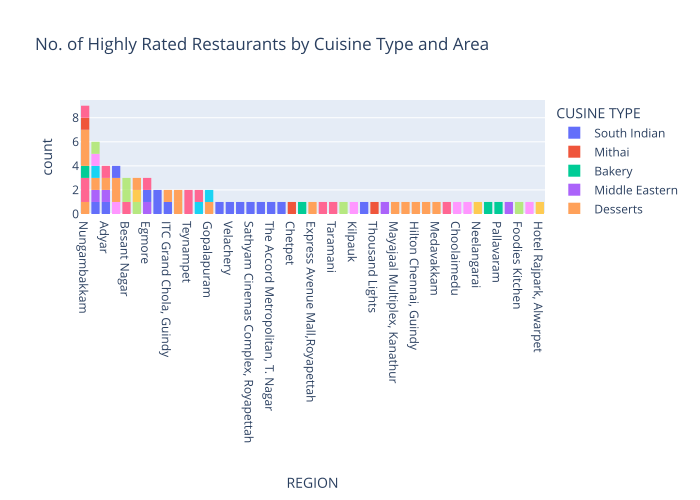

In [32]:
##5. Performing Exploratory Data Analysis

## Q5) Which areas have the highest rated restaurants by primary cuisine type in Chennai?

fig = px.histogram(
    highest_rated_df, x='REGION', color='CUSINE TYPE',
    title='No. of Highly Rated Restaurants by Cuisine Type and Area'
).update_xaxes(categoryorder='total descending')
fig.show()

In [33]:
##5. Performing Exploratory Data Analysis

## Q6) What is the average price distribution of highly rated restaurants by cuisine type in Chennai?

highest_rated_price_df = highest_rated_df.groupby(
    by=['REGION', 'CUSINE TYPE']
)['PRICE'].mean().reset_index()
highest_rated_price_df.head()

,REGION,CUSINE TYPE,PRICE
0,Adyar,Chinese,800.0
1,Adyar,Ice Cream,200.0
2,Adyar,North Indian,1800.0
3,Adyar,South Indian,500.0
4,Alwarpet,Desserts,350.0


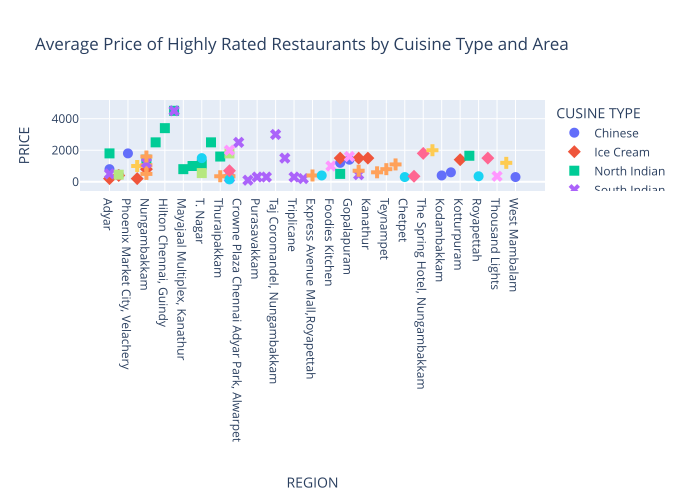

In [34]:
##5. Performing Exploratory Data Analysis

## Q6) What is the average price distribution of highly rated restaurants by cuisine type in Chennai?

fig = px.scatter(
    highest_rated_price_df, x='REGION', y='PRICE',
    color='CUSINE TYPE', symbol='CUSINE TYPE',
    title='Average Price of Highly Rated Restaurants by Cuisine Type and Area'
).update_traces(marker_size=10)
fig.show()

In [35]:
##5. Performing Exploratory Data Analysis

## Q7) Which areas have a large number of Chinese restaurants?

chinese_df = zomato_df[zomato_df['CUSINE_CATEGORY'].str.contains('Chinese', case=False, na=False)]
chinese_df.head()

,URL,NAME,Address,REGION,CUSINE_CATEGORY,Top Dishes,PRICE,RATING,VOTES,Delivery Rating,Delivery Rating Count,Features,CUSINE TYPE,RATING_TYPE
2,https://www.zomato.com/chennai/ss-hyderabad-bi...,SS Hyderabad Biryani,"98/339, Arcot Road, Opposite Gokulam Chit Fun...",Kodambakkam,"['Biryani', ' North Indian', ' Chinese', ' Ara...","['Brinjal Curry', ' Tandoori Chicken', ' Chick...",500.0,4.3,1361.0,4.4,10500.0,"['Home Delivery', 'Indoor Seating']",Biryani,Very Good
4,https://www.zomato.com/chennai/tasty-kitchen-p...,Tasty Kitchen,"135B, SRP Colony, Peravallur, Near Perambur, ...",Perambur,"['Chinese', ' Biryani', ' North Indian', ' Che...","['Mutton Biryani', ' Chicken Rice', ' Tomato R...",450.0,4.2,617.0,4.1,22400.0,"['Home Delivery', 'Indoor Seating']",Chinese,Very Good
5,https://www.zomato.com/chennai/dine-n-fun-meda...,Dine N Fun,"Opposite Forest Office, Tambaram Main Road, S...",Medavakkam,"['South Indian', ' North Indian', ' Chinese']","['Chicken Grill', ' Shawarma', ' Naan', ' Chic...",450.0,4.1,567.0,3.8,24700.0,"['Home Delivery', 'Indoor Seating']",South Indian,Very Good
8,https://www.zomato.com/chennai/savoury-sea-she...,Savoury Sea Shell,"3, E Block, 3rd Avenue, Anna Nagar East, Chennai",Anna Nagar East,"['Arabian', ' Chinese', ' North Indian', ' Leb...","['Shawarma', ' Chicken Grill', ' Brownie', ' S...",1400.0,4.2,2564.0,4.1,21700.0,"['Home Delivery', 'Indoor Seating', 'Card Upon...",Arabian,Very Good
9,https://www.zomato.com/chennai/sangeetha-veg-r...,Sangeetha Veg Restaurant,"102/82, GN Chetty Road, T. Nagar, Chennai",T. Nagar,"['South Indian', ' North Indian', ' Chinese', ...","['Filtered Coffee', ' Chaat', ' Faluda', ' Mas...",800.0,4.4,1578.0,4.2,39600.0,"['Breakfast', 'Home Delivery', 'Vegetarian Onl...",South Indian,Very Good


In [36]:
##5. Performing Exploratory Data Analysis

## Q7) Which areas have a large number of Chinese restaurants?

chinese_rest_df = chinese_df.groupby(by='REGION').agg(
    {'NAME': 'count', 'PRICE': 'mean'}
).rename(columns={'NAME': 'COUNT OF RESTAURANTS'}).reset_index()

chinese_rest_df = chinese_rest_df.sort_values(
    'COUNT OF RESTAURANTS', ascending=False
).head(25)
chinese_rest_df.head()

,REGION,COUNT OF RESTAURANTS,PRICE
139,Porur,81,459.876543
165,T. Nagar,71,516.901408
7,Ambattur,68,402.941176
12,Anna Nagar East,66,613.636364
134,Perambur,66,446.212121


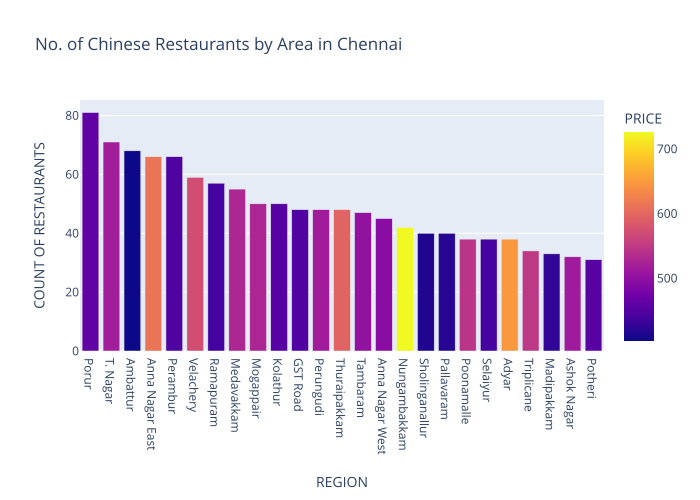

In [37]:
##5. Performing Exploratory Data Analysis

## Q7) Which areas have a large number of Chinese restaurants?

fig = px.bar(
    chinese_rest_df, x='REGION', y='COUNT OF RESTAURANTS',
    color='PRICE', title='No. of Chinese Restaurants by Area in Chennai'
)
fig.show()

In [38]:
##5. Performing Exploratory Data Analysis

## Q8) Is there a relation between price and dining rating by primary cuisine type?

price_rating_df = zomato_df.groupby(
    ['CUSINE TYPE', 'RATING']
)['PRICE'].mean().reset_index()
price_rating_df.head()

,CUSINE TYPE,RATING,PRICE
0,American,2.4,800.0
1,American,2.7,300.0
2,American,3.3,250.0
3,American,3.9,600.0
4,American,4.1,1200.0


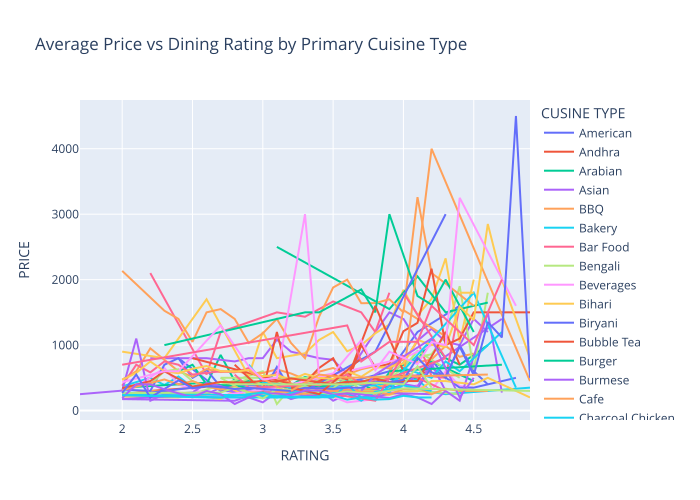

In [39]:
##5. Performing Exploratory Data Analysis

## Q8) Is there a relation between price and dining rating by primary cuisine type?

fig = px.line(price_rating_df, y='PRICE', x='RATING', color='CUSINE TYPE',
              title='Average Price vs Dining Rating by Primary Cuisine Type')
fig.show()

In [40]:
##5. Performing Exploratory Data Analysis

## Q9) Is there a relation between area and average price in Chennai?

region_price_df = zomato_df.groupby(['REGION'])['PRICE'].mean().reset_index()
region_price_df.head()

,REGION,PRICE
0,Abhiramapuram,150.000000
1,"Abu Sarovar Portico, Egmore",1000.000000
2,Adambakkam,308.730159
3,Adyar,520.081967
4,Akkarai,768.181818


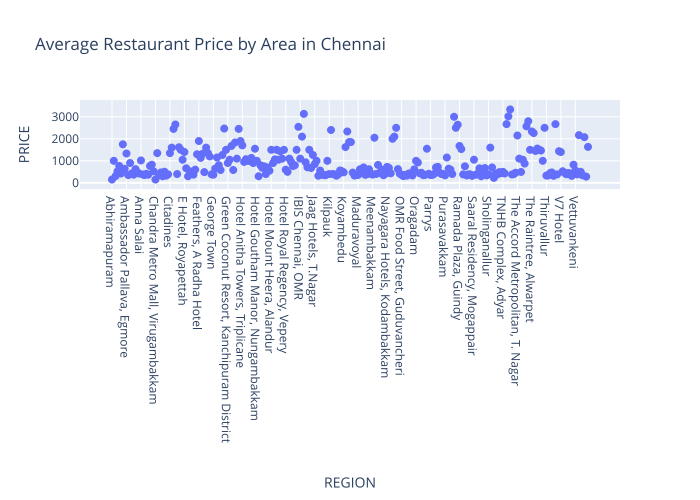

In [41]:
##5. Performing Exploratory Data Analysis

## Q9) Is there a relation between area and average price in Chennai?

fig = px.scatter(region_price_df, x='REGION', y='PRICE',
                 title='Average Restaurant Price by Area in Chennai').update_traces(marker_size=8)
fig.show()

In [42]:
##5. Performing Exploratory Data Analysis

## Q10) Find affordable restaurants in Chennai

# Find restaurants with price for two less than or equal to one-fourth of the maximum listed price
max_price = zomato_df['PRICE'].max()
one_fourth_price = max_price / 4
one_fourth_price

1250.0

In [43]:
##5. Performing Exploratory Data Analysis

## Q10) Find affordable restaurants in Chennai

aff_rest_df = zomato_df[['NAME', 'PRICE', 'CUSINE_CATEGORY', 'REGION', 'CUSINE TYPE']]
aff_rest_df = aff_rest_df[aff_rest_df['PRICE'] <= one_fourth_price].copy()
aff_rest_df = aff_rest_df.sort_values(by='PRICE')
aff_rest_df.head(25)

,NAME,PRICE,CUSINE_CATEGORY,REGION,CUSINE TYPE
4685,Soda Hub,40.0,['Beverages'],"OMR Food Street, Navallur",Beverages
1448,Mamee Soup,60.0,['Healthy Food'],West Mambalam,Healthy Food
2254,MKN Madurai Idly Kadai,100.0,['South Indian'],Tambaram,South Indian
5228,Hotel Purushothaman,100.0,"['South Indian', ' North Indian']",Saidapet,South Indian
2278,Prithvika Fast Food,100.0,"['South Indian', ' Chinese']",Ramapuram,South Indian
5208,Al Malik Spice Chat,100.0,['Street Food'],Santhome,Street Food
2151,Cane 4 U,100.0,['Beverages'],Besant Nagar,Beverages
5316,New Rolex Bakery & Sweets,100.0,"['Bakery', ' Beverages']",Tambaram,Bakery
1980,Rohini Restaurant,100.0,['North Indian'],Porur,North Indian
5160,Royal Ice Cream,100.0,"['Ice Cream', ' Desserts']",Avadi,Ice Cream


In [44]:
##5. Performing Exploratory Data Analysis

## Q11) Find highly rated restaurants in Chennai

highrate_rest_df = zomato_df[['NAME', 'PRICE', 'CUSINE_CATEGORY', 'REGION', 'CUSINE TYPE', 'RATING']]
highrate_rest_df = highrate_rest_df[highrate_rest_df['RATING'] >= 4.5].copy()
highrate_rest_df.sort_values(by='PRICE').head(25)

,NAME,PRICE,CUSINE_CATEGORY,REGION,CUSINE TYPE,RATING
108,Rayar's Mess,100.0,['South Indian'],Mylapore,South Indian,4.7
178,Royal Sandwich Shop,150.0,"['Fast Food', ' Desserts', ' Beverages']",Alwarpet,Fast Food,4.7
50,Andhikkadai,200.0,['South Indian'],Velachery,South Indian,4.6
154,Nair Mess,200.0,"['South Indian', ' Biryani']",Triplicane,South Indian,4.5
320,Bombay Kulfi,200.0,['Ice Cream'],Adyar,Ice Cream,4.9
9541,Bombay Kulfi,200.0,['Ice Cream'],Anna Nagar East,Ice Cream,4.6
24,Eating Circles,250.0,['South Indian'],Alwarpet,South Indian,4.7
15,Welcome Hotel,300.0,"['South Indian', ' Desserts', ' Beverages']",Purasavakkam,South Indian,4.5
270,ID,300.0,['South Indian'],"Sathyam Cinemas Complex, Royapettah",South Indian,4.5
37,Shree Mithai,300.0,"['Mithai', ' Street Food', ' Fast Food']",Chetpet,Mithai,4.6


In [45]:
##5. Performing Exploratory Data Analysis

## Q12) Find affordable restaurants with high dining ratings

# Affordable restaurants with low price and high rating
highrate_aff_df = pd.merge(
    aff_rest_df, highrate_rest_df, how='inner', on=['NAME', 'REGION'],
    suffixes=('_affordable', '_rated')
)
highrate_aff_df = highrate_aff_df[
    ['NAME', 'PRICE_affordable', 'CUSINE_CATEGORY_affordable', 'REGION', 'CUSINE TYPE_affordable']
].rename(columns={
    'PRICE_affordable': 'PRICE',
    'CUSINE_CATEGORY_affordable': 'CUSINE_CATEGORY',
    'CUSINE TYPE_affordable': 'CUSINE TYPE'
})
highrate_aff_df.head()

,NAME,PRICE,CUSINE_CATEGORY,REGION,CUSINE TYPE
0,Rayar's Mess,100.0,['South Indian'],Mylapore,South Indian
1,Royal Sandwich Shop,150.0,"['Fast Food', ' Desserts', ' Beverages']",Alwarpet,Fast Food
2,Royal Sandwich Shop,150.0,"['Fast Food', ' Desserts', ' Beverages']",Alwarpet,Fast Food
3,Royal Sandwich Shop,150.0,"['Fast Food', ' Desserts', ' Beverages']",Alwarpet,Fast Food
4,Bombay Kulfi,200.0,['Ice Cream'],Anna Nagar East,Ice Cream


In [46]:
##5. Performing Exploratory Data Analysis

## Q13) What is the average number of dining reviews for restaurants in Chennai?

mean_votes = zomato_df['VOTES'].mean()
mean_votes

np.float64(135.7671520792674)

In [47]:
##5. Performing Exploratory Data Analysis

## Q13) Find restaurants with more than the average number of dining reviews

mean_rest_df = zomato_df[['NAME', 'PRICE', 'CUSINE_CATEGORY', 'REGION', 'CUSINE TYPE', 'VOTES']]
mean_rest_df = mean_rest_df[mean_rest_df['VOTES'] >= mean_votes].copy()
mean_rest_df.sort_values(by='VOTES').head(25)

,NAME,PRICE,CUSINE_CATEGORY,REGION,CUSINE TYPE,VOTES
10135,Madrasi Biryani,400.0,"['Biryani', ' South Indian']",Kelambakkam,Biryani,136.0
9677,Drunken Monkey,400.0,"['Beverages', ' Fast Food']",Alwarpet,Beverages,136.0
1306,Nachiyar Authentic Chettinad Restaurant,700.0,"['North Indian', ' Chinese', ' Chettinad']",Kolathur,North Indian,136.0
9002,Domino's Pizza,400.0,"['Pizza', ' Fast Food']",Porur,Pizza,136.0
9052,A2B - Adyar Ananda Bhavan,600.0,"['South Indian', ' North Indian', ' Chinese', ...",Anna Nagar East,South Indian,136.0
9193,Subway,500.0,"['Healthy Food', ' Fast Food']",Gopalapuram,Healthy Food,136.0
1147,KoKoMMo,1500.0,['Finger Food'],"InterContinental Chennai Mahabalipuram Resort,...",Finger Food,137.0
1304,Ek Aur Paratha,300.0,"['North Indian', ' Street Food', ' Sandwich']",Gopalapuram,North Indian,137.0
1116,Adaminde Thattukada,500.0,['South Indian'],Besant Nagar,South Indian,137.0
1101,The Grand Sweets and Snacks,250.0,"['Street Food', ' South Indian', ' Chettinad',...",Adyar,Street Food,137.0


In [48]:
##5. Performing Exploratory Data Analysis

## Q14) Find reliable and affordable restaurants with high ratings and above-average review counts

reliable_rest_df = pd.merge(
    mean_rest_df, highrate_aff_df, how='inner', on=['NAME', 'REGION'],
    suffixes=('_reviews', '_affordable')
)
reliable_rest_df.head()

,NAME,PRICE_reviews,CUSINE_CATEGORY_reviews,REGION,CUSINE TYPE_reviews,VOTES,PRICE_affordable,CUSINE_CATEGORY_affordable,CUSINE TYPE_affordable
0,Welcome Hotel,300.0,"['South Indian', ' Desserts', ' Beverages']",Purasavakkam,South Indian,1094.0,300.0,"['South Indian', ' Desserts', ' Beverages']",South Indian
1,Eating Circles,250.0,['South Indian'],Alwarpet,South Indian,782.0,250.0,['South Indian'],South Indian
2,Shree Mithai,300.0,"['Mithai', ' Street Food', ' Fast Food']",Chetpet,Mithai,1085.0,300.0,"['Mithai', ' Street Food', ' Fast Food']",Mithai
3,Andhikkadai,200.0,['South Indian'],Velachery,South Indian,908.0,200.0,['South Indian'],South Indian
4,Brownie Heaven,350.0,"['Bakery', ' Desserts', ' Beverages']",Royapettah,Bakery,842.0,350.0,"['Bakery', ' Desserts', ' Beverages']",Bakery


In [49]:
##5. Performing Exploratory Data Analysis

## Q15) Compare dining ratings and delivery ratings

rating_compare_df = zomato_df[['NAME', 'REGION', 'RATING', 'Delivery Rating', 'PRICE']].dropna(
    subset=['RATING', 'Delivery Rating']
)
rating_compare_df.head()

,NAME,REGION,RATING,Delivery Rating,PRICE
0,Yaa Mohaideen Briyani,Pallavaram,4.3,4.3,500.0
1,Sukkubhai Biriyani,Alandur,4.4,4.1,1000.0
2,SS Hyderabad Biryani,Kodambakkam,4.3,4.4,500.0
3,KFC,Perambur,4.0,4.0,500.0
4,Tasty Kitchen,Perambur,4.2,4.1,450.0


In [52]:
##5. Performing Exploratory Data Analysis

## Q15) Compare dining ratings and delivery ratings

fig = px.scatter(
    rating_compare_df, x='RATING', y='Delivery Rating', color='PRICE',
    title='Dining Rating vs Delivery Rating for Chennai Restaurants',
    hover_data=['NAME', 'REGION'])


fig.write_image("dining_vs_delivery_ratings.png")


![Dining Rating vs Delivery Rating for Chennai Restaurants](dining_vs_delivery_ratings.png)